#**karkeb project**

---




#**Loading data**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:

customers = pd.read_csv("Customers 4.csv", encoding="latin1")
products = pd.read_csv("products5.csv")
sales = pd.read_csv("Sales.csv")
stores = pd.read_csv("Stores.csv")
rates = pd.read_csv("Exchange_Rates.csv")

#**cleaning data**

---



In [23]:
products.columns = products.columns.str.strip()
customers.columns = customers.columns.str.strip()
sales.columns = sales.columns.str.strip()
stores.columns = stores.columns.str.strip()
rates.columns = rates.columns.str.strip()

#**Price cleaning removes $ and converts it to a number**

In [26]:
products["Unit Price USD"] = (
    products["Unit Price USD"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

products["Unit Price USD"] = pd.to_numeric(
    products["Unit Price USD"], errors="coerce"
)

In [30]:
products["Unit Price USD"].fillna(
    products["Unit Price USD"].median(),
    inplace=True
)

/tmp/ipython-input-724657251.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products["Unit Price USD"].fillna(


In [31]:
data = sales.merge(products, on="ProductKey", how="left")
data = data.merge(customers, on="CustomerKey", how="left")
data = data.merge(stores, on="StoreKey", how="left")

In [33]:
data["Total Sales"] = data["Quantity"] * data["Unit Price USD"]
data

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,Product Name,...,State_x,Zip Code,Country_x,Continent,Birthday,Country_y,State_y,Square Meters,Open Date,Total Sales
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD,Contoso Lens Adapter M450 White,...,Ontario,N5W 5K6,Canada,North America,3/23/1971,Canada,Nunavut,1210.0,4/4/2015,68.00
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD,A. Datum SLR Camera X136 Silver,...,California,93602,United States,North America,11/20/1995,Online,Online,NaN,1/1/2010,854.00
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD,Fabrikam Microwave 1.5CuFt X1100 Black,...,California,93602,United States,North America,11/20/1995,Online,Online,NaN,1/1/2010,665.94
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD,Contoso SLR Camera M146 Orange,...,Alberta,T4N 2A6,Canada,North America,8/24/1962,Online,Online,NaN,1/1/2010,2254.00
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD,Adventure Works Laptop8.9 E0890 White,...,Alberta,T4N 2A6,Canada,North America,8/24/1962,Online,Online,NaN,1/1/2010,326.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,1,2/20/2021,NaN,1216913,43,632,3,USD,WWI Screen 85in E1010 White,...,California,92643,United States,North America,4/16/1939,United States,Alaska,1190.0,1/1/2015,417.00
62880,2243031,1,2/20/2021,2/24/2021,511229,0,98,4,EUR,WWI Wireless Bluetooth Stereo Headphones M170 ...,...,Baden-Württemberg,70184,Germany,Europe,3/10/1940,Online,Online,NaN,1/1/2010,480.00
62881,2243032,1,2/20/2021,2/23/2021,331277,0,1613,2,CAD,SV DVD 7-Inch Player Portable E200 White,...,Alberta,T2T 0C6,Canada,North America,5/25/1993,Online,Online,NaN,1/1/2010,219.98
62882,2243032,2,2/20/2021,2/23/2021,331277,0,1717,2,CAD,MGS Flight Simulator X M250,...,Alberta,T2T 0C6,Canada,North America,5/25/1993,Online,Online,NaN,1/1/2010,140.26


In [34]:
top_products = (
    data.groupby("Product Name")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
WWI Desktop PC2.33 X2330 Black                 505450.00
Adventure Works Desktop PC2.33 XD233 Silver    466089.00
Adventure Works Desktop PC2.33 XD233 Brown     464151.00
Adventure Works Desktop PC2.33 XD233 Black     447678.00
Adventure Works Desktop PC2.33 XD233 White     437019.00
WWI Desktop PC2.33 X2330 White                 424578.00
WWI Desktop PC2.33 X2330 Brown                 422740.00
Adventure Works 52" LCD HDTV X590 White        394398.64
Adventure Works 52" LCD HDTV X590 Black        374098.71
WWI Desktop PC2.33 X2330 Silver                360248.00
Name: Total Sales, dtype: float64


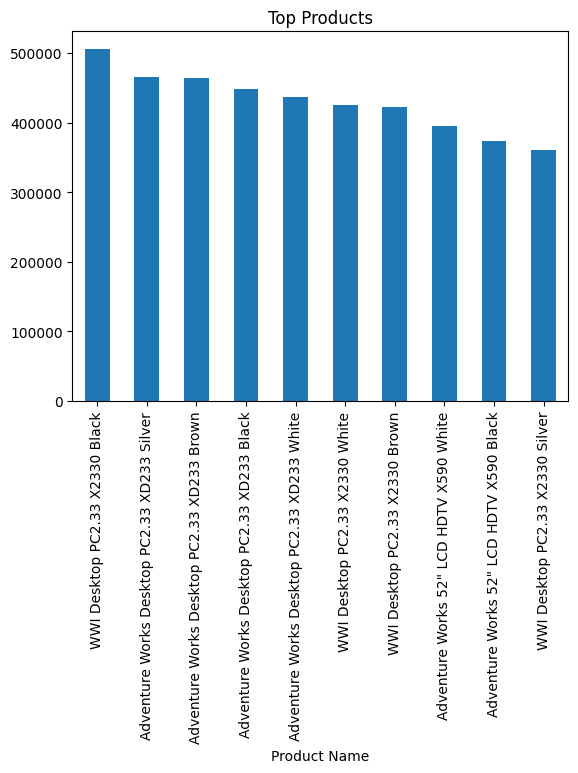

In [35]:
top_products.plot(kind="bar")
plt.title("Top Products")
plt.show()

In [47]:
customers.info()
products.info()
sales.info()
stores.info()
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CustomerKey  15266 non-null  int64 
 1   Gender       15266 non-null  object
 2   Name         15266 non-null  object
 3   City         15266 non-null  object
 4   State Code   15256 non-null  object
 5   State        15266 non-null  object
 6   Zip Code     15266 non-null  object
 7   Country      15266 non-null  object
 8   Continent    15266 non-null  object
 9   Birthday     15266 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ProductKey      2517 non-null   int64  
 1   Product Name    2517 non-null   object 
 2   Brand           2517 non-null   object 
 3   Color       

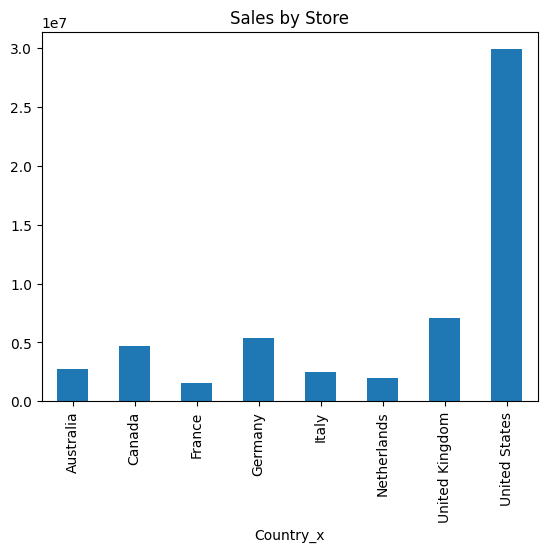

In [56]:
sales_by_Country_x= data.groupby("Country_x" )["Total Sales"].sum()
sales_by_Country_x.plot(kind="bar")
plt.title("Sales by Store")
plt.show()

In [57]:
print(data.columns)

Index(['Order Number', 'Line Item', 'Order Date', 'Delivery Date',
       'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code',
       'Product Name', 'Brand', 'Color', 'Unit Cost USD', 'Unit Price USD',
       'SubcategoryKey', 'Subcategory', 'CategoryKey', 'Category', 'Gender',
       'Name', 'City', 'State Code', 'State_x', 'Zip Code', 'Country_x',
       'Continent', 'Birthday', 'Country_y', 'State_y', 'Square Meters',
       'Open Date', 'Total Sales'],
      dtype='object')


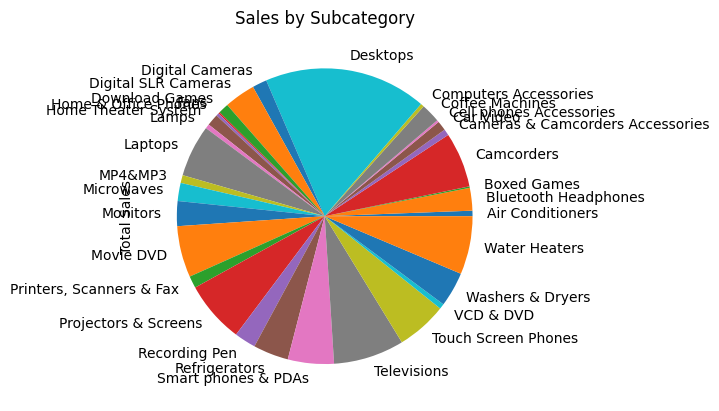

In [62]:
sales_by_Subcategory= data.groupby("Subcategory")["Total Sales"].sum()
sales_by_Subcategory.plot(kind="pie")
plt.title("Sales by Subcategory")
plt.show()

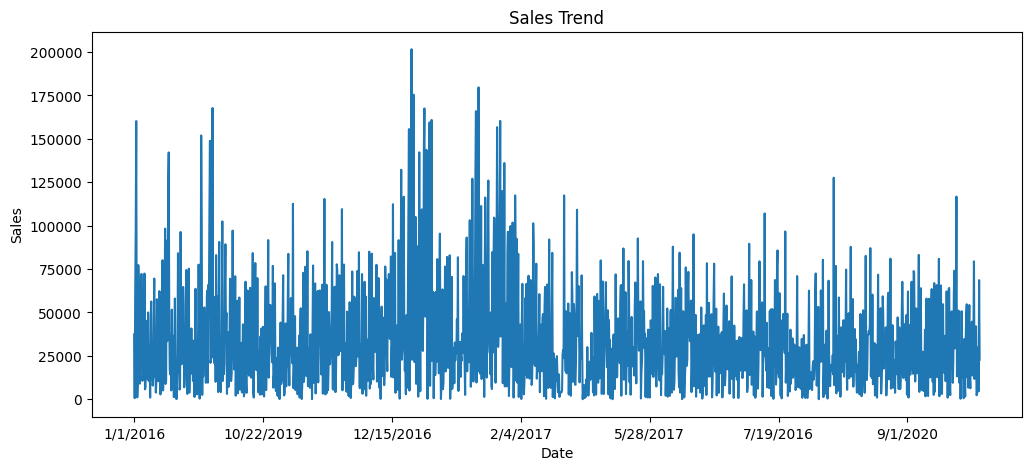

In [67]:
sales_by_OrderDate.plot(figsize=(12,5))
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

#**recommend the most sales**

---



In [68]:
recommended_products = (
    data.groupby("Product Name")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Recommended Products:")
print(recommended_products)

Recommended Products:
Product Name
WWI Desktop PC2.33 X2330 Black                 505450.0
Adventure Works Desktop PC2.33 XD233 Silver    466089.0
Adventure Works Desktop PC2.33 XD233 Brown     464151.0
Adventure Works Desktop PC2.33 XD233 Black     447678.0
Adventure Works Desktop PC2.33 XD233 White     437019.0
Name: Total Sales, dtype: float64


#**
For a specific customer**

---



In [69]:
customer_id = data["CustomerKey"].iloc[0]

customer_data = data[data["CustomerKey"] == customer_id]

fav_category = (
    customer_data.groupby("Category")["Total Sales"]
    .sum()
    .idxmax()
)

recommend_for_customer = (
    data[data["Category"] == fav_category]
    .groupby("Product Name")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(recommend_for_customer)

Product Name
WWI Desktop PC2.33 X2330 Black                 505450.0
Adventure Works Desktop PC2.33 XD233 Silver    466089.0
Adventure Works Desktop PC2.33 XD233 Brown     464151.0
Adventure Works Desktop PC2.33 XD233 Black     447678.0
Adventure Works Desktop PC2.33 XD233 White     437019.0
Name: Total Sales, dtype: float64
